In [29]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

In [30]:
# Data transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images ke 224x224
    transforms.RandomHorizontalFlip(),  # Horizontal flip augmentation
    transforms.ToTensor(),  # Ubah ke tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # ImageNet normalization
])

# Load dataset
train_dataset = datasets.ImageFolder('training_data', transform=transform)
test_dataset = datasets.ImageFolder('test_data', transform=transform)

# DataLoader
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [31]:
torch.cuda.is_available()

True

In [32]:
print("Labels in dataset:")
print(train_dataset.classes[:2])

Labels in dataset:
['AiArt', 'RealArt']


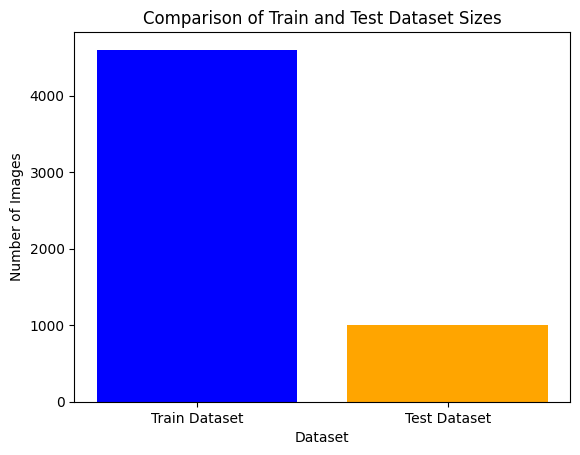

In [33]:
train_size = len(train_dataset)
test_size = len(test_dataset)

datasets = ['Train Dataset', 'Test Dataset']
sizes = [train_size, test_size]

plt.bar(datasets, sizes, color=['blue', 'orange'])
plt.xlabel('Dataset')
plt.ylabel('Number of Images')
plt.title('Comparison of Train and Test Dataset Sizes')
plt.show()

In [ ]:
# Load pretrained ResNet50 model
model = models.resnet50(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

In [35]:
# Loss function dan optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.002)

In [36]:
from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

num_epochs = 15
best_accuracy = 0.0

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [37]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

# DataLoader
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Train accuracy
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_accuracy = 100 * train_correct / train_total
    avg_train_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    running_val_loss = 0.0
    
    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_outputs = model(val_inputs)

            loss = criterion(val_outputs, val_labels)
            running_val_loss += loss.item() 

            _, val_predicted = torch.max(val_outputs, 1)
            val_total += val_labels.size(0)
            val_correct += (val_predicted == val_labels).sum().item()
    
    val_accuracy = 100 * val_correct / val_total
    avg_val_loss = running_val_loss / len(val_loader)

    # Simpan riwayat loss dan akurasi
    train_loss_history.append(avg_train_loss)
    train_acc_history.append(train_accuracy)
    val_loss_history.append(avg_val_loss)
    val_acc_history.append(val_accuracy)
    
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Train Acc: {train_accuracy:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_accuracy:.2f}%")
    
    # Save best model
    if train_accuracy > best_accuracy:
        best_accuracy = train_accuracy
        torch.save(model.state_dict(), 'best_model.pth')

print(f"Best training Accuracy: {best_accuracy:.2f}%")

c:\Users\acern\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/15 | Train Loss: 0.4489 | Train Acc: 82.50% | Val Loss: 0.3097 | Val Acc: 89.13%
Epoch 2/15 | Train Loss: 0.2919 | Train Acc: 87.80% | Val Loss: 0.2449 | Val Acc: 89.78%
Epoch 3/15 | Train Loss: 0.2373 | Train Acc: 90.35% | Val Loss: 0.2195 | Val Acc: 91.52%
Epoch 4/15 | Train Loss: 0.2105 | Train Acc: 91.14% | Val Loss: 0.2022 | Val Acc: 92.07%
Epoch 5/15 | Train Loss: 0.1842 | Train Acc: 91.74% | Val Loss: 0.1905 | Val Acc: 91.74%
Epoch 6/15 | Train Loss: 0.1655 | Train Acc: 93.10% | Val Loss: 0.1791 | Val Acc: 92.28%
Epoch 7/15 | Train Loss: 0.1436 | Train Acc: 94.18% | Val Loss: 0.1846 | Val Acc: 92.83%
Epoch 8/15 | Train Loss: 0.1289 | Train Acc: 94.81% | Val Loss: 0.1735 | Val Acc: 92.50%
Epoch 9/15 | Train Loss: 0.1141 | Train Acc: 95.38% | Val Loss: 0.1737 | Val Acc: 93.15%
Epoch 10/15 | Train Loss: 0.1061 | Train Acc: 96.25% | Val Loss: 0.1769 | Val Acc: 92.72%
Epoch 11/15 | Train Loss: 0.0884 | Train Acc: 96.66% | Val Loss: 0.1643 | Val Acc: 93.37%
Epoch 12/15 | Train

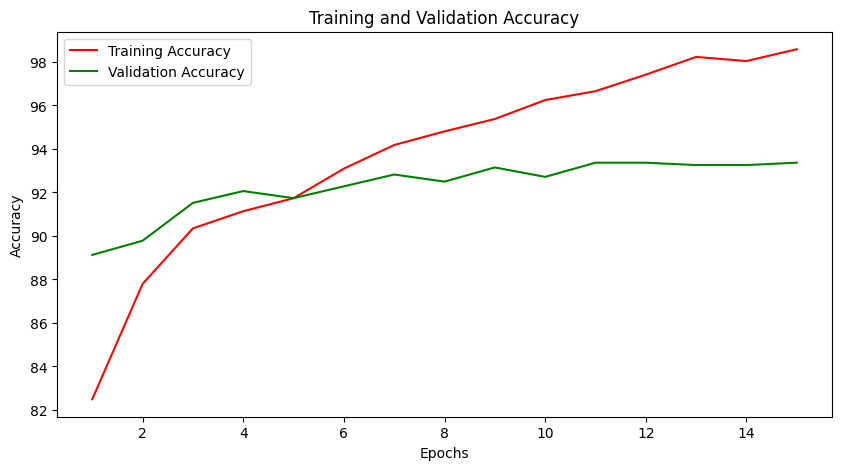

In [38]:
# Membuat plot untuk Akurasi
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_acc_history, 'r', label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_acc_history, 'g', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

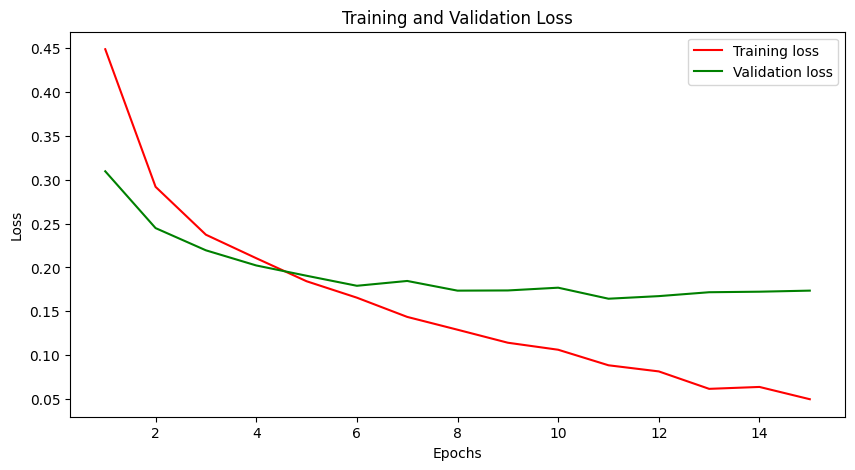

In [39]:
# Membuat plot untuk Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_loss_history, 'r', label='Training loss')
plt.plot(range(1, num_epochs + 1), val_loss_history, 'g', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [40]:
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

correct = 0
total = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

final_accuracy = 100 * correct / total
print(f"Final Test Accuracy: {final_accuracy:.2f}%")

Final Test Accuracy: 97.30%


In [41]:
# Classification report
target_names = train_dataset.classes
report = classification_report(all_labels, all_predictions, target_names=target_names)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

       AiArt       0.96      0.98      0.97       499
     RealArt       0.98      0.96      0.97       500

    accuracy                           0.97       999
   macro avg       0.97      0.97      0.97       999
weighted avg       0.97      0.97      0.97       999



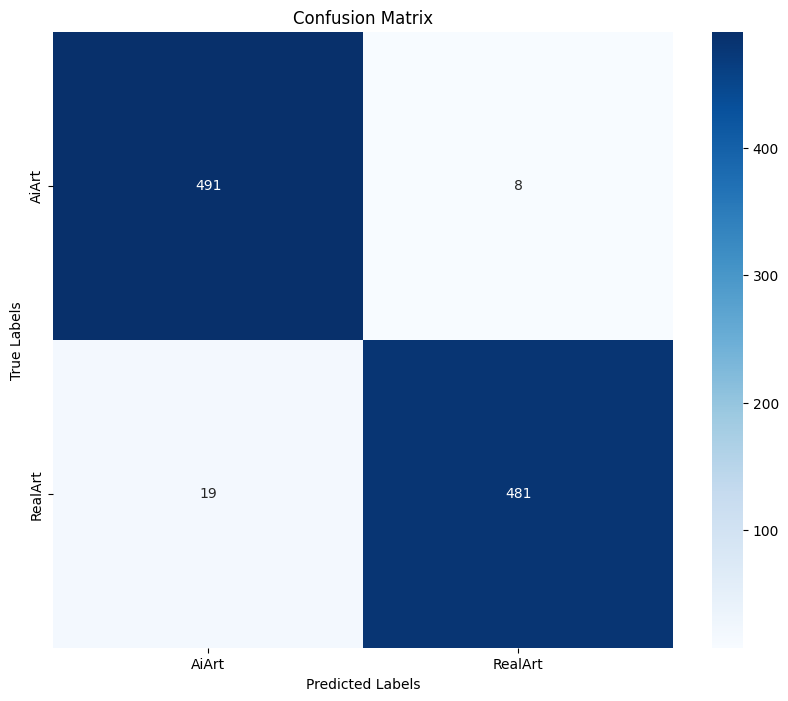

In [42]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()